In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
#코랩 업로드용
from google.colab import files
uploaded = files.upload()


Saving train.csv to train.csv


In [12]:
# 데이터 불러오기
df = pd.read_csv("train.csv")
df.head(5)

,ID,설립연도,국가,분야,투자단계,직원 수,인수여부,상장여부,고객수(백만명),총 투자금(억원),연매출(억원),SNS 팔로워 수(백만명),기업가치(백억원),성공확률
0,TRAIN_0000,2009,CT005,이커머스,Series A,4126.0,No,No,56.0,3365.0,4764.0,4.71,NaN,0.3
1,TRAIN_0001,2023,CT006,핀테크,Seed,4167.0,Yes,No,80.0,4069.0,279.0,1.00,2500-3500,0.8
2,TRAIN_0002,2018,CT007,기술,Series A,3132.0,Yes,Yes,54.0,6453.0,12141.0,4.00,3500-4500,0.5
3,TRAIN_0003,2016,CT006,NaN,Seed,3245.0,Yes,Yes,NaN,665.0,10547.0,2.97,NaN,0.7
4,TRAIN_0004,2020,CT002,에듀테크,Seed,1969.0,No,Yes,94.0,829.0,9810.0,1.00,1500-2500,0.1


### 간단한 EDA 진행

In [13]:
# 1. 데이터 크기 확인
print("데이터 크기:", df.shape)

데이터 크기: (4376, 14)


In [14]:
# 2. 기본 정보 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4376 entries, 0 to 4375
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              4376 non-null   object 
 1   설립연도            4376 non-null   int64  
 2   국가              4376 non-null   object 
 3   분야              3519 non-null   object 
 4   투자단계            4376 non-null   object 
 5   직원 수            4202 non-null   float64
 6   인수여부            4376 non-null   object 
 7   상장여부            4376 non-null   object 
 8   고객수(백만명)        3056 non-null   float64
 9   총 투자금(억원)       4376 non-null   float64
 10  연매출(억원)         4376 non-null   float64
 11  SNS 팔로워 수(백만명)  4376 non-null   float64
 12  기업가치(백억원)       3156 non-null   object 
 13  성공확률            4376 non-null   float64
dtypes: float64(6), int64(1), object(7)
memory usage: 478.8+ KB


In [15]:
# 3. 기초 통계량 확인
print(df.describe())

              설립연도         직원 수     고객수(백만명)    총 투자금(억원)       연매출(억원)  \
count  4376.000000  4202.000000  3056.000000  4376.000000   4376.000000   
mean   2012.006856  2471.324369    49.214332  3314.568556   6452.202239   
std       6.554872  1446.064215    27.141242  1880.103831   3782.792656   
min    2001.000000     5.000000     1.000000    12.000000     12.000000   
25%    2006.000000  1218.250000    27.000000  1651.500000   3094.250000   
50%    2012.000000  2472.000000    49.000000  3398.000000   6478.500000   
75%    2018.000000  3727.500000    72.000000  4908.250000   9692.500000   
max    2023.000000  4998.000000    99.000000  7059.000000  14822.000000   

       SNS 팔로워 수(백만명)         성공확률  
count     4376.000000  4376.000000  
mean         2.578103     0.537340  
std          1.414590     0.241698  
min          0.000000     0.100000  
25%          1.320000     0.400000  
50%          2.835000     0.600000  
75%          4.000000     0.700000  
max          5.000000     0.

In [16]:
# 4. 결측치 개수 확인
print("\n결측치 개수:\n", df.isnull().sum())


결측치 개수:
 ID                   0
설립연도                 0
국가                   0
분야                 857
투자단계                 0
직원 수               174
인수여부                 0
상장여부                 0
고객수(백만명)          1320
총 투자금(억원)            0
연매출(억원)              0
SNS 팔로워 수(백만명)       0
기업가치(백억원)         1220
성공확률                 0
dtype: int64


In [17]:
# 한글 폰트 정상 출력을 위한 설정
import matplotlib.font_manager as fm
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

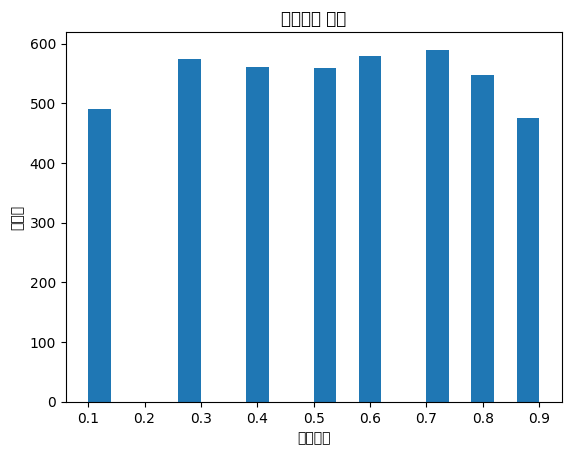

In [18]:
# 5. 목표 변수('성공확률')의 분포 시각화

plt.hist(df['성공확률'], bins=20)
plt.title('성공확률 분포')
plt.xlabel('성공확률')
plt.ylabel('빈도수')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49444 (\N{HANGUL SYLLABLE SEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 47549 (\N{HANGUL SYLLABLE RIB}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51649 (\N{HANGUL SYLLABLE JIG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/u

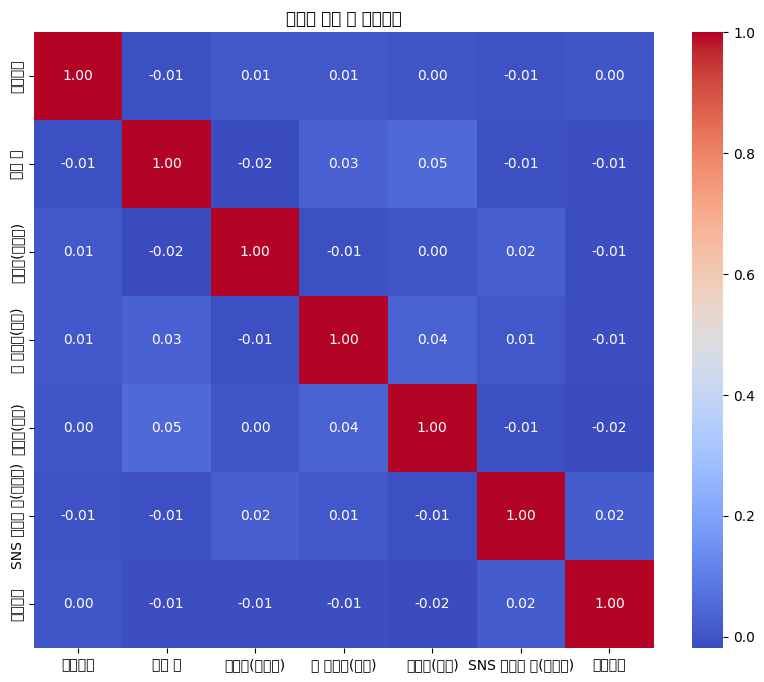

In [19]:
# 6. 수치형 변수 간 상관관계
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title('수치형 변수 간 상관관계')
plt.show()

### 전처리  

In [20]:
# 1. 'ID' 칼럼 삭제
df.drop(columns=['ID'], inplace=True)

In [21]:
# 2. '분야' 칼럼 결측치 'Unknown' 처리
df['분야'] = df['분야'].fillna('Unknown')

In [22]:
# 3. '직원 수', '고객수(백만명)' 칼럼 결측치 'median' 대체
for col in ['직원 수', '고객수(백만명)']:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

In [23]:
# 4. '기업가치' 칼럼 전처리

# 범주형 칼럼 '기업가치'를 하한값으로 변환하는 함수
def convert_to_lower_limit(value):

    # 값이 NaN이면 그대로 반환
    if pd.isna(value):
        return np.nan

    # 값이 '문자열'이면 특수 문자 '-' 포함 여부 확인
    if isinstance(value, str):

        # 값이 '6000이상' -> 6000.0으로 변환
        if value == '6000이상':
            return 6000.0

        # 값이 특수 문자 '-' 포함한 범주형 -> 하한값('-' 앞의 값)만 추출
        if '-' in value:
            return float(value.split('-')[0])

        # 값이 '-'없이 숫자만 문자열 형태로 있는 경우 -> float 변환
        return float(value)

    return value

# 함수 적용
df['기업가치(백억원)'] = df['기업가치(백억원)'].apply(convert_to_lower_limit)

# 남은 결측치(NaN) -> 전체의 중앙값(median)으로 대체
df['기업가치(백억원)'] = df['기업가치(백억원)'].fillna(df['기업가치(백억원)'].median())

In [24]:
# 5. 범주형 데이터 처리
from sklearn.preprocessing import LabelEncoder

# '인수여부', '상장여부' -> Label Encoding
label_cols = ['인수여부', '상장여부']
for col in label_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# '국가', '분야', '투자단계' -> One - Hot Encoding
onehot_cols = ['국가', '분야', '투자단계']
df = pd.get_dummies(df, columns=onehot_cols)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4376 entries, 0 to 4375
Data columns (total 36 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   설립연도            4376 non-null   int64  
 1   직원 수            4376 non-null   float64
 2   인수여부            4376 non-null   int64  
 3   상장여부            4376 non-null   int64  
 4   고객수(백만명)        4376 non-null   float64
 5   총 투자금(억원)       4376 non-null   float64
 6   연매출(억원)         4376 non-null   float64
 7   SNS 팔로워 수(백만명)  4376 non-null   float64
 8   기업가치(백억원)       4376 non-null   float64
 9   성공확률            4376 non-null   float64
 10  국가_CT001        4376 non-null   bool   
 11  국가_CT002        4376 non-null   bool   
 12  국가_CT003        4376 non-null   bool   
 13  국가_CT004        4376 non-null   bool   
 14  국가_CT005        4376 non-null   bool   
 15  국가_CT006        4376 non-null   bool   
 16  국가_CT007        4376 non-null   bool   
 17  국가_CT008        4376 non-null   b

In [27]:
# 이상치 확인
import pandas as pd

# int64, float64 타입 컬럼만 골라 리스트로
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()

outlier_summary = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary.append({
        "Feature": col,
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "LowerBound": round(lower, 2),
        "UpperBound": round(upper, 2),
        "OutlierCount": len(outliers)
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.sort_values(by="OutlierCount", ascending=False))


          Feature       Q1       Q3      IQR  LowerBound  UpperBound  \
0            설립연도  2006.00  2018.00    12.00     1988.00     2036.00   
1            직원 수  1272.00  3675.25  2403.25    -2332.88     7280.12   
2            인수여부     0.00     1.00     1.00       -1.50        2.50   
3            상장여부     0.00     1.00     1.00       -1.50        2.50   
4        고객수(백만명)    37.00    62.00    25.00       -0.50       99.50   
5       총 투자금(억원)  1651.50  4908.25  3256.75    -3233.62     9793.38   
6         연매출(억원)  3094.25  9692.50  6598.25    -6803.12    19589.88   
7  SNS 팔로워 수(백만명)     1.32     4.00     2.68       -2.70        8.02   
8       기업가치(백억원)  2500.00  4500.00  2000.00     -500.00     7500.00   
9            성공확률     0.40     0.70     0.30       -0.05        1.15   

   OutlierCount  
0             0  
1             0  
2             0  
3             0  
4             0  
5             0  
6             0  
7             0  
8             0  
9             0  


In [28]:
# 음수가 나오면 안 되는 주요 변수 리스트
columns_to_check = [
    '직원 수', '고객수(백만명)', '총 투자금(억원)', '연매출(억원)',
    'SNS 팔로워 수(백만명)', '기업가치(백억원)'
]

# 변수별로 음수값 존재 여부 확인
for col in columns_to_check:
    negative_count = (df[col] < 0).sum()
    print(f"{col}: {negative_count} rows with negative values")


직원 수: 0 rows with negative values
고객수(백만명): 0 rows with negative values
총 투자금(억원): 0 rows with negative values
연매출(억원): 0 rows with negative values
SNS 팔로워 수(백만명): 0 rows with negative values
기업가치(백억원): 0 rows with negative values


**이상치도 딱히 없고, 음수 값 데이터도 없어서 이상치는 특별히 처리하지 않도록 하겠습니다**

In [29]:
# 기준 연도 설정
CURRENT_YEAR = 2025

# 업력 파생변수 생성 (한글 컬럼명 기준) (업력: 쉽게 말해 기업의 나이)
df['업력'] = CURRENT_YEAR - df['설립연도'] + 1


In [30]:
# 작은 수 ε 설정 (0으로 나누는 것 방지)
epsilon = 1e-5


In [31]:
# 매출대비투자비율 생성
epsilon = 1e-5
df['매출대비투자비율'] = df['연매출(억원)'] / (df['총 투자금(억원)'] + epsilon)

# 성공확률 기준 그룹 나누기
threshold = 0.7
high = df[df['성공확률'] > threshold]['매출대비투자비율']
low = df[df['성공확률'] <= threshold]['매출대비투자비율']

# Mann-Whitney U test
from scipy.stats import mannwhitneyu
stat, p = mannwhitneyu(high, low, alternative='two-sided')

print(f"U 통계량: {stat:.2f}")
print(f"p-value: {p:.5f}")

if p < 0.05:
    print("✅ 통계적으로 유의한 차이가 있음 (파생변수 의미 있음)")
else:
    print("⚠️ 통계적으로 유의하지 않음 (파생변수 의미 약함)")


U 통계량: 1711294.00
p-value: 0.91523
⚠️ 통계적으로 유의하지 않음 (파생변수 의미 약함)


In [ ]:
# 기업가치 성장 속도 파생변수 생성
epsilon = 1e-5
df['기업가치성장속도'] = df['기업가치(백억원)'] / (df['업력'] + epsilon)

# 고성공 vs 저성공 그룹 분리
threshold = 0.7
high_group = df[df['성공확률'] > threshold]['기업가치성장속도']
low_group = df[df['성공확률'] <= threshold]['기업가치성장속도']

# Mann-Whitney U test
stat, p = mannwhitneyu(high_group, low_group, alternative='two-sided')

# 결과 출력
print(f"U 통계량: {stat:.2f}")
print(f"p-value: {p:.5f}")

if p < 0.05:
    print("✅ 통계적으로 유의한 차이가 있음 (파생변수 의미 있음)")
else:
    print("⚠️ 통계적으로 유의하지 않음 (파생변수 의미 약함)")

U 통계량: 1700874.00
p-value: 0.68837
⚠️ 통계적으로 유의하지 않음 (파생변수 의미 약함)


In [34]:
from sklearn.model_selection import train_test_split

# 1) 특성(feature) 컬럼 정의 (타깃인 '성공확률'은 제외)
feature_cols = [col for col in df.columns if col != '성공확률']
X = df[feature_cols]

# 2) 타깃(target) 정의
# 회귀 대신 분류를 원하면, 예를 들어 성공확률 > 0.7 을 1, 아니면 0 으로 라벨링:
threshold = 0.7
y = (df['성공확률'] > threshold).astype(int)

# 3) 학습/검증 데이터 분할
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # 클래스 비율 유지
)

# 4) 그리드 서치로 튜닝
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMClassifier

param_grid = {
    'n_estimators': [50, 100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50]
}

grid = GridSearchCV(
    estimator=LGBMClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best n_estimators:", grid.best_params_['n_estimators'])
print("Best score (AUC):", grid.best_score_)





[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 818, number of negative: 2682
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000163 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1469
[LightGBM] [Info] Number of data points in the train set: 3500, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.233714 -> initscore=-1.187456
[LightGBM] [Info] Start training from score -1.187456
Best n_estimators: 200
Best score (AUC): 0.551679044387789


In [35]:
!pip install lightgbm scikit-learn pandas



In [36]:
from google.colab import files
uploaded = files.upload()  # 파일 선택 창이 뜸


Saving train.csv to train (1).csv


In [42]:
# 1) 필요한 라이브러리 임포트
import numpy as np
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

# 2) 모델 초기화
lgbm_clf = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

# 3) 콜백 정의
callbacks = [
    lgb.early_stopping(stopping_rounds=100, first_metric_only=True),
    lgb.log_evaluation(period=50)
]

# 4) 모델 학습 (eval_set에 validation 세트 넣기)
lgbm_clf.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    callbacks=callbacks  # verbose 인자는 여기서 빼주세요
)

# 5) 검증 세트 예측 (확률)
y_pred_proba = lgbm_clf.predict_proba(X_val)[:, 1]

# 6) ROC AUC 계산
lgbm_roc_score = roc_auc_score(y_val, y_pred_proba)
print(f'Validation ROC AUC: {lgbm_roc_score:.4f}')




[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 818, number of negative: 2682
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000272 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1469
[LightGBM] [Info] Number of data points in the train set: 3500, number of used features: 37
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.233714 -> initscore=-1.187456
[LightGBM] [Info] Start training from score -1.187456
Training until validation scores don't improve for 100 rounds
[50]	valid_0's auc: 0.558475	valid_0's binary_logloss: 0.543922
[100]	valid_0's auc: 0.581426	valid_0's binary_logloss: 0.541423
[150]	valid_0's auc: 0.579768	valid_0's binary_logloss: 0.546295
[200]	valid_0's auc: 0.586173	

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/

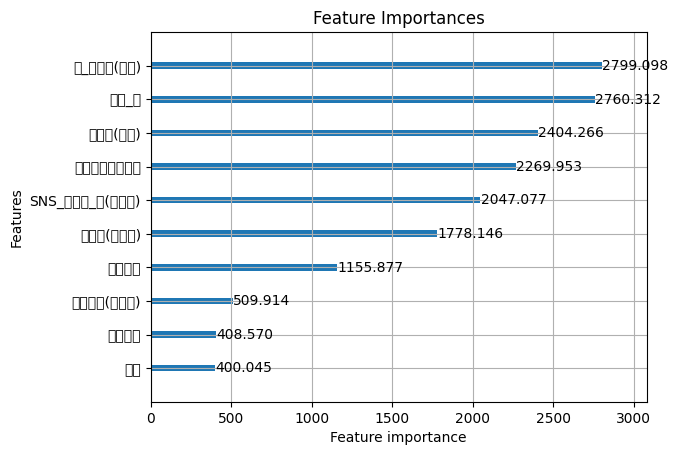

In [44]:
import matplotlib.pyplot as plt
import lightgbm as lgb

# sklearn 래퍼인 LGBMClassifier를 직접 넘기기
lgb.plot_importance(
    lgbm_clf,            # gbm → lgbm_clf 로 수정
    max_num_features=10,
    importance_type='gain'  # 기본 값, 필요시 'split' 으로 바꿀 수 있어요
)
plt.title("Feature Importances")
plt.show()


In [46]:
import pandas as pd

# feature_importances_ 속성 사용
feature_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgbm_clf.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feature_imp.head(10))



           feature  importance
5        총 투자금(억원)         879
1             직원 수         833
6          연매출(억원)         748
36        매출대비투자비율         696
7   SNS 팔로워 수(백만명)         606
4         고객수(백만명)         546
0             설립연도         336
8        기업가치(백억원)         159
35              업력         132
3             상장여부         119


In [49]:
# Colab 셀에 먼저 실행
!apt-get update -qq
!apt-get install fonts-nanum -qq
!fc-cache -fv



W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped dire

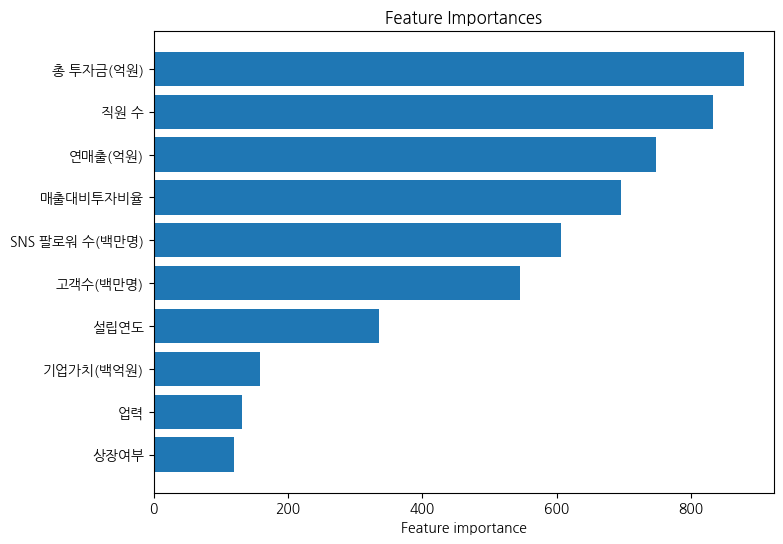

In [50]:
# 파이썬 셀에서

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm

# 1) 나눔고딕 파일 경로 가져오기
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

# 2) 폰트 매니저에 폰트 추가
fm.fontManager.addfont(font_path)

# 3) rc 설정
mpl.rc('font', family='NanumGothic')
mpl.rcParams['axes.unicode_minus'] = False  # 음수 기호 깨짐 방지

# 4) 다시 그려보기
feature_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgbm_clf.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(8,6))
plt.barh(feature_imp['feature'].head(10), feature_imp['importance'].head(10))
plt.xlabel('Feature importance')
plt.title('Feature Importances')
plt.gca().invert_yaxis()
plt.show()
